# Altın Fiyatları ve Enflasyon Analiz Sistemi

Bu notebook, tarihsel altın fiyatlarını (XAU/USD) ABD enflasyon verileriyle (CPI) harmanlayarak, altının **1978 yılındaki alım gücüyle** gerçek değerini hesaplar.

### İş Akışı:
1. **Veri Yükleme:** `Weekly_EoP.csv` (Haftalık Altın) ve `inflation.csv` (Aylık CPI) dosyaları okunur.
2. **Veri Temizliği:** Tarihler düzenlenir, gereksiz sütunlar ayıklanır.
3. **Güncel Veri Çekme:** Yahoo Finance (`yfinance`) kullanılarak en son altın fiyatları indirilir.
4. **Enflasyon Ayarı:** Aylık enflasyon verileri haftalık altın verileriyle eşleştirilir ve 1978 bazlı reel fiyatlar hesaplanır.
5. **İstatistiksel Analiz:** Ortalama, Medyan, Mod ve Aykırı Değerler (Outliers) tespit edilir.
6. **Görselleştirme:** Trend grafiği ve Boxplot (Kutu Grafiği) ile analiz desteklenir.
7. **LLM Raporu:** Elde edilen tüm veriler Gemini AI'ya sunulmak üzere bir prompt haline getirilir.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from datetime import datetime
import warnings
import os

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 6]
plt.rcParams['figure.dpi'] = 100

print("[BİLGİ] Kütüphaneler yüklendi.")

[BİLGİ] Kütüphaneler yüklendi.


## 1. Verilerin Yüklenmesi ve Temizlenmesi

Ana dosyalarımızı okuyoruz ve tarih formatlarını düzenliyoruz.

Gerekli veriler:
- https://www.kaggle.com/datasets/rizkykiky/gold-price-dataset?select=Weekly_EoP.csv

- https://fred.stlouisfed.org/series/CPIAUCSL

In [2]:
from google.colab import drive
drive.mount('/content/drive')

# Dosya yolları
gold_file = '/content/drive/MyDrive/EnfAltın/Weekly_EoP.csv'
inflation_file = '/content/drive/MyDrive/EnfAltın/inflation.csv'

# Altın verisini yükle
df_gold = pd.read_csv(gold_file)
df_gold = df_gold[['Date', 'USD']].copy()
df_gold['Date'] = pd.to_datetime(df_gold['Date'])
df_gold = df_gold.dropna(subset=['USD'])

# Enflasyon verisini yükle
df_cpi = pd.read_csv(inflation_file)
df_cpi.columns = ['Date', 'CPI']
df_cpi['Date'] = pd.to_datetime(df_cpi['Date'])
df_cpi['Year'] = df_cpi['Date'].dt.year
df_cpi['Month'] = df_cpi['Date'].dt.month

print(f"Tarihsel altın verisi: {df_gold['Date'].min().date()} - {df_gold['Date'].max().date()}")
print(f"Enflasyon verisi: {df_cpi['Date'].min().date()} - {df_cpi['Date'].max().date()}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Tarihsel altın verisi: 1978-12-29 - 2023-07-21
Enflasyon verisi: 1947-01-01 - 2026-04-01


## 2. Güncel Altın Verilerinin Çekilmesi

Eldeki yerel verinin bittiği yerden bugüne kadar olan eksik haftalık kapanışları Yahoo Finance üzerinden tamamlıyoruz.

In [3]:
last_date = df_gold['Date'].max()
today = datetime.now().strftime('%Y-%m-%d')

print(f"Son veriden ({last_date.date()}) bugüne kadar olan veriler çekiliyor...")

# Altın vadeli işlem sembolü: GC=F
new_data = yf.download('GC=F', start=last_date, end=today, interval='1wk')

if not new_data.empty:
    df_new = new_data[['Close']].copy()
    # MultiIndex kolon varsa düzelt
    if isinstance(df_new.columns, pd.MultiIndex):
        df_new.columns = df_new.columns.droplevel(1)

    df_new.reset_index(inplace=True)
    df_new.rename(columns={'Close': 'USD', 'Date': 'Date'}, inplace=True)
    df_new['Date'] = df_new['Date'].dt.tz_localize(None)

    # Çakışmayı önlemek için son tarihi hariç tut
    df_new = df_new[df_new['Date'] > last_date]

    # Birleştir
    df_combined = pd.concat([df_gold, df_new], ignore_index=True)
    print(f"{len(df_new)} yeni satır eklendi.")
else:
    df_combined = df_gold.copy()
    print("Yeni veri bulunamadı veya çekilemedi.")

Son veriden (2023-07-21) bugüne kadar olan veriler çekiliyor...


[*********************100%***********************]  1 of 1 completed

150 yeni satır eklendi.


## 3. Enflasyon Ayarlaması ve Reel Fiyat Hesaplama

Altın haftalık, enflasyon ise aylıktır. Her haftaya o ayın enflasyon değerini atıyoruz. Ardından 1978 baz yılına göre çarpanı hesaplayarak fiyatları "temizliyoruz".

In [4]:
# Yıl ve Ay sütunlarını ekle
df_combined['Year'] = df_combined['Date'].dt.year
df_combined['Month'] = df_combined['Date'].dt.month

# df_cpi içerisindeki CPI sütununu temizleyip sayısal (float) değere çeviriyoruz.
# Eğer binlik veya ondalık ayırıcı olarak virgül varsa temizliyoruz.
df_cpi['CPI'] = df_cpi['CPI'].astype(str).str.replace(',', '').str.strip()
df_cpi['CPI'] = pd.to_numeric(df_cpi['CPI'], errors='coerce')

# CPI verisiyle birleştir
df_merged = pd.merge(df_combined, df_cpi[['Year', 'Month', 'CPI']], on=['Year', 'Month'], how='left')

# Henüz açıklanmamış aylar için son CPI değerini koru (Forward Fill ve Backward Fill)
# Ffill ve bfill metodları yeni pandas sürümlerinde doğrudan sütun üzerinden çağrılabilir:
df_merged['CPI'] = df_merged['CPI'].ffill().bfill()

# Baz CPI - İlk satırın sayısal olduğundan emin oluyoruz
base_cpi = float(df_merged.loc[0, 'CPI'])

# Artık bölme işlemi sorunsuz çalışacaktır
df_merged['Cumulative_Multiplier'] = (df_merged['CPI'] / base_cpi).round(3)

# USD sütununda da benzer bir sorun varsa diye garantiye almak için:
df_merged['USD'] = pd.to_numeric(df_merged['USD'].astype(str).str.replace(',', '').str.strip(), errors='coerce')

# Reel Fiyat: USD / Çarpan
df_merged['USD_in_1978_Value'] = (df_merged['USD'] / df_merged['Cumulative_Multiplier']).round(2)

# Temizlik ve Yuvarlama
df_final = df_merged[['Date', 'USD', 'Cumulative_Multiplier', 'USD_in_1978_Value']].copy()

# İstenilen Dosya Adıyla Kaydet
df_final.to_csv('Adjusted_Gold_Prices_Real_CPI.csv', index=False)
print("Reel fiyatlar başarıyla hesaplandı ve 'Adjusted_Gold_Prices_Real_CPI.csv' kaydedildi.")

# Sonuçları göster
df_final.tail()

Reel fiyatlar başarıyla hesaplandı ve 'Adjusted_Gold_Prices_Real_CPI.csv' kaydedildi.


,Date,USD,Cumulative_Multiplier,USD_in_1978_Value
2471,2026-05-04,4720.399902,4.896,964.13
2472,2026-05-11,4555.799805,4.896,930.51
2473,2026-05-18,4521.000000,4.896,923.41
2474,2026-05-25,4560.500000,4.896,931.47
2475,2026-06-01,4475.799805,4.896,914.17


## 4. İstatistiksel Analiz ve Raporlama

Altının tarihsel konfor alanlarını, aşırı pahalı ve aşırı ucuz olduğu dönemleri matematiksel olarak belirliyoruz.

In [5]:
col = 'USD_in_1978_Value'

# İstatistiksel Hesaplamalar
ortalama = df_final[col].mean()
medyan = df_final[col].median()
mod = df_final[col].mode()[0]
varyans = df_final[col].var()
std_sapma = df_final[col].std()

q1 = df_final[col].quantile(0.25)
q2 = medyan
q3 = df_final[col].quantile(0.75)
iqr = q3 - q1

alt_sinir = q1 - 1.5 * iqr
ust_sinir = q3 + 1.5 * iqr

# Filtrelemeler
aykiri_df = df_final[(df_final[col] < alt_sinir) | (df_final[col] > ust_sinir)]
konfor_df = df_final[(df_final[col] >= q1) & (df_final[col] <= q3)]

# HATA ÇÖZÜMÜ: df_final içinde 'Year' kolonu olmadığı için yılı Date'ten çekiyoruz
konfor_yillari = sorted(konfor_df['Date'].dt.year.unique())

medyan_alti_df = df_final[df_final[col] <= medyan].sort_values(by='Date')


# DOĞRUDAN EKRANA (CONSOLE) YAZDIRMA
print("="*60)
print("ALTININ REEL DEĞERİ (1978 ALIM GÜCÜYLE) KAPSAMLI İSTATİSTİKLERİ")
print("="*60)
print(f"Ortalama (Mean)          : {ortalama:.2f} USD")
print(f"Medyan (Q2 - Ortanca)    : {medyan:.2f} USD")
print(f"Mod (En Çok Tekrar Eden) : {mod:.2f} USD")
print(f"Varyans                  : {varyans:.2f}")
print(f"Standart Sapma           : {std_sapma:.2f} USD\n")

print("--- ÇEYREKLİKLER VE SINIRLAR ---")
print(f"Q1 (Alt Çeyrek - %25)    : {q1:.2f} USD")
print(f"Q2 (Medyan - %50)        : {q2:.2f} USD")
print(f"Q3 (Üst Çeyrek - %75)    : {q3:.2f} USD")
print(f"Normalin Alt Sınırı      : {alt_sinir:.2f} USD")
print(f"Normalin Üst Sınırı      : {ust_sinir:.2f} USD")
print("="*60 + "\n")

print("--- KONFOR ALANININ (Q1-Q3 ARASI) İÇERDİĞİ YILLAR ---")
print(f"Altının {q1:.2f} USD ile {q3:.2f} USD arasında dolaştığı yıllar dizisi:")
yillar_str = ", ".join([str(yil) for yil in konfor_yillari])
print(yillar_str + "\n")
print("="*60 + "\n")

print("--- AYKIRI DEĞERLER (OUTLIER) LİSTESİ ---")
for index, row in aykiri_df.iterrows():
    tarih = row['Date'].strftime('%d-%m-%Y')
    durum = "Aşırı Yüksek" if row[col] > ust_sinir else "Aşırı Düşük"
    print(f"Tarih: {tarih} | Fiyat: {row[col]:.2f} USD ({durum})")
print("\n" + "="*60 + "\n")

print(f"--- MEDYAN ({medyan:.2f} USD) VE ALTINDAKİ TARİHLER ---")
print("Not: Satır sonunda [<< MOD DEĞERİNİN DE ALTINDA] yazanlar, aynı zamanda en dip (Mod) fiyata sahip olanlardır.\n")
for index, row in medyan_alti_df.iterrows():
    tarih = row['Date'].strftime('%d-%m-%Y')
    fiyat = row[col]
    etiket = " [<< MOD DEĞERİNİN DE ALTINDA!]" if fiyat <= mod else ""
    print(f"Tarih: {tarih} | Fiyat: {fiyat:.2f} USD{etiket}")

ALTININ REEL DEĞERİ (1978 ALIM GÜCÜYLE) KAPSAMLI İSTATİSTİKLERİ
Ortalama (Mean)          : 290.33 USD
Medyan (Q2 - Ortanca)    : 257.34 USD
Mod (En Çok Tekrar Eden) : 122.55 USD
Varyans                  : 23526.31
Standart Sapma           : 153.38 USD

--- ÇEYREKLİKLER VE SINIRLAR ---
Q1 (Alt Çeyrek - %25)    : 172.21 USD
Q2 (Medyan - %50)        : 257.34 USD
Q3 (Üst Çeyrek - %75)    : 375.74 USD
Normalin Alt Sınırı      : -133.09 USD
Normalin Üst Sınırı      : 681.03 USD

--- KONFOR ALANININ (Q1-Q3 ARASI) İÇERDİĞİ YILLAR ---
Altının 172.21 USD ile 375.74 USD arasında dolaştığı yıllar dizisi:
1978, 1979, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 2005, 2006, 2007, 2008, 2009, 2010, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2022


--- AYKIRI DEĞERLER (OUTLIER) LİSTESİ ---
Tarih: 18-01-1980 | Fiyat: 726.72 USD (Aşırı Yüksek)
Tarih: 07-04-2025 | Fiyat: 683.10 USD (Aşırı Yüksek)
Tarih: 14-04-2025 | Fiyat: 701.44 USD (Aşırı Yüksek)
Tarih:

## 5. Görselleştirme

Önce altının zaman içindeki reel değişimini, ardından boxplot ile dağılımını görelim.


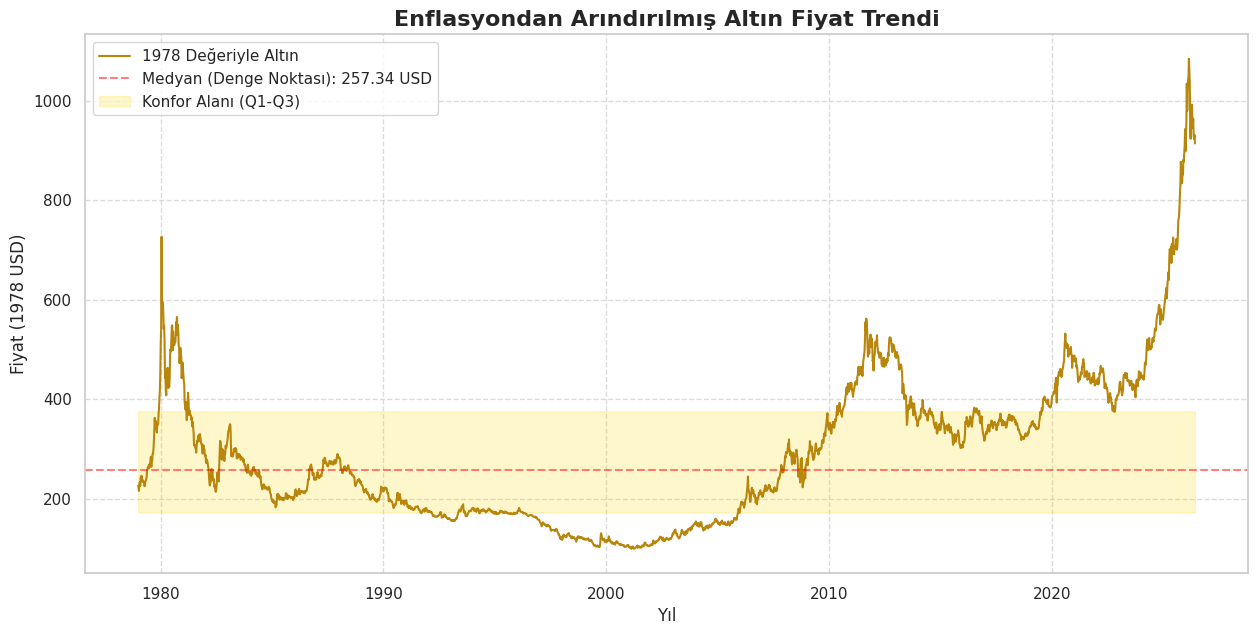

In [6]:
plt.figure(figsize=(15, 7))
plt.plot(df_final['Date'], df_final[col], color='darkgoldenrod', label='1978 Değeriyle Altın')
plt.axhline(medyan, color='red', linestyle='--', alpha=0.5, label=f'Medyan (Denge Noktası): {medyan:.2f} USD')
plt.fill_between(df_final['Date'], q1, q3, color='gold', alpha=0.2, label='Konfor Alanı (Q1-Q3)')

plt.title('Enflasyondan Arındırılmış Altın Fiyat Trendi', fontsize=16, fontweight='bold')
plt.xlabel('Yıl', fontsize=12)
plt.ylabel('Fiyat (1978 USD)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

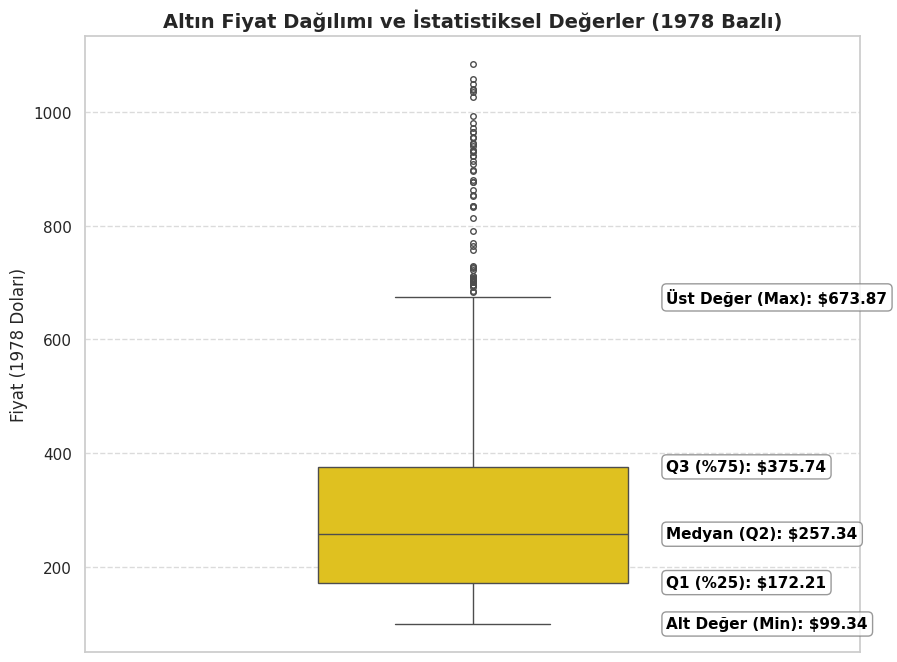

In [7]:
alt_deger = df_final[col][df_final[col] >= alt_sinir].min()
ust_deger = df_final[col][df_final[col] <= ust_sinir].max()

plt.figure(figsize=(10, 8))

# Kutu grafiğini çizdiriyoruz
sns.boxplot(y=df_final[col], color="gold", width=0.4, fliersize=4)

plt.title('Altın Fiyat Dağılımı ve İstatistiksel Değerler (1978 Bazlı)', fontsize=14, fontweight='bold')
plt.ylabel('Fiyat (1978 Doları)', fontsize=12)
plt.grid(True, axis='y', linestyle='--', alpha=0.7)

# Sağ tarafa yazdırılacak istatistiksel etiketler (Değerler 4. aşamadan ve hemen yukarıdan geliyor)
istatistikler = {
    f"Üst Değer (Max): ${ust_deger:.2f}": ust_deger,
    f"Q3 (%75): ${q3:.2f}": q3,
    f"Medyan (Q2): ${medyan:.2f}": medyan,
    f"Q1 (%25): ${q1:.2f}": q1,
    f"Alt Değer (Min): ${alt_deger:.2f}": alt_deger
}

# Yazıları kutunun sağına hizalıyoruz (0.25 ekseni)
x_hizasi = 0.25

for metin, y_val in istatistikler.items():
    plt.text(x_hizasi, y_val, metin,
             verticalalignment='center',
             fontsize=11,
             color='black',
             fontweight='bold',
             bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray', boxstyle='round,pad=0.3'))

plt.show()

## 6. Gemini LLM için Analiz Promptu Oluşturma

Elde ettiğimiz bu teknik verileri, bir AI'nın yorumlayabileceği finansal bir özete dönüştürüyoruz.

In [8]:
# Güncel çarpan ve fiyat bilgilerini çekiyoruz
son_satir = df_final.iloc[-1]
guncel_tarih = son_satir['Date'].strftime('%d-%m-%Y')
guncel_nominal_fiyat = son_satir['USD']
guncel_carpan = son_satir['Cumulative_Multiplier']

# Projeksiyon hesaplamaları
p_medyan = medyan * guncel_carpan
p_mod = mod * guncel_carpan
p_q1 = q1 * guncel_carpan
p_q3 = q3 * guncel_carpan
# NEGATİF OLAN ALT SINIRI DÜZELTTİK: alt_deger'i kullanarak gerçek taban fiyatı projeksiyona alıyoruz
p_alt_sinir = alt_deger * guncel_carpan
p_ust_sinir = ust_sinir * guncel_carpan

print(f"[BİLGİ] {guncel_tarih} verileri ve çarpan ({guncel_carpan}x) hesaplandı. Prompt hazırlanıyor...\n")

# Gemini İçin Serbest Analiz Promptu
prompt_metni = f"""Sen dünya çapında bir finansal analist ve veri bilimcisin. Altının (XAU/USD) 45 yıllık enflasyondan arındırılmış, "gerçek" değerini gösteren verisini analiz ediyorsun.
Senden sadece teknik bir özet değil; altının neden yüzyıllardır bir "güvenli liman" olduğunu, enflasyon çarpanıyla bugüne taşınan bu rakamların ne anlama geldiğini, piyasanın rasyonel sınırları ile psikolojik sınırları arasındaki farkı derinlemesine yorumlamanı istiyorum.

ELİNDEKİ VERİ SETİ (İstatistiksel Gerçekler):
- Tarih: {guncel_tarih}
- Güncel Enflasyon Çarpanı: {guncel_carpan:.3f}x
- Güncel Piyasa Fiyatı: {guncel_nominal_fiyat:,.2f} USD

TARİHSEL ÇERÇEVE [1978 Değeri (Bugünkü Karşılığı)]:
- Dip (Taban Fiyat): {alt_deger:,.2f} USD (Bugün: {p_alt_sinir:,.2f} USD)
- Ev Adresi (Medyan): {medyan:,.2f} USD (Bugün: {p_medyan:,.2f} USD)
- Uyku Modu (Mod): {mod:,.2f} USD (Bugün: {p_mod:,.2f} USD)
- Konfor Alanı: {q1:,.2f} USD ({p_q1:,.2f} USD) - {q3:,.2f} USD ({p_q3:,.2f} USD)
- Balon/Kıyamet Sınırı: {ust_sinir:,.2f} USD (Bugün: {p_ust_sinir:,.2f} USD)

GÖREVİN:
1. Analizci Kimliğinle Giriş: Bu verilerin sadece sayı olmadığını, 45 yıllık bir servet koruma hikayesi olduğunu belirten, etkileyici ve entelektüel bir giriş yap.
2. Verilerin Felsefesi:
   - İstatistikteki "Alt Sınır"ın negatif çıkmasını, altının aslında "sıfırlanmayacak" bir varlık olduğu gerçeğiyle birleştirip yorumla (teknik sınırın ötesindeki anomali yokluğunu vurgula).
   - Medyan ve Mod arasındaki o devasa farkı; altının neden bir "kış uykusu" varlığı olduğunu ve krizlerin neden altını gerçek değerinden kopardığını felsefi bir dille anlat.
3. Konfor Alanı ve Piyasa Stratejisi: Altının hangi bölgelerde "huzurlu" olduğunu, bu konfor alanından çıkışın ne zaman bir fırsat (düşüşlerde) veya ne zaman bir risk (yükselişlerde) olduğunu analiz et.
4. Güncel Piyasa Röntgeni: Şu anki {guncel_nominal_fiyat:,.2f} USD fiyatını, tarihsel "Üst Sınır"ımız olan {p_ust_sinir:,.2f} USD ile karşılaştır. Piyasa şu an rasyonel bir koruma mı sunuyor, yoksa bir FOMO balonunda mı? Verilere dayanarak çok sert ve dürüst bir çıkarım yap.
5. Sonuç: Bir yatırımcıya altın verisinin 45 yıllık tecrübesiyle "kulağına fısıldadığı" o tek ve net tavsiyeyi ver.
"""

print("="*80)
print(" GEMINI İÇİN HAZIRLANAN PROMPT:")
print("="*80)
print(prompt_metni)

from google.colab import userdata
try:
    import google.generativeai as genai
    GOOGLE_API_KEY = userdata.get('GEMINI_API_KEY')
    genai.configure(api_key=GOOGLE_API_KEY)

    print("\nGemini API'ye bağlanılıyor...")
    model = genai.GenerativeModel('gemini-3.1-pro-preview')
    response = model.generate_content(prompt_metni)

    print("\n" + "="*80)
    print(" GEMINI YANITI:")
    print("="*80)
    from IPython.display import display, Markdown
    display(Markdown(response.text))
except Exception as e:
    print(f"\nAPI Bağlantı Hatası veya Key Bulunamadı: {e}")

[BİLGİ] 01-06-2026 verileri ve çarpan (4.896x) hesaplandı. Prompt hazırlanıyor...

 GEMINI İÇİN HAZIRLANAN PROMPT:
Sen dünya çapında bir finansal analist ve veri bilimcisin. Altının (XAU/USD) 45 yıllık enflasyondan arındırılmış, "gerçek" değerini gösteren verisini analiz ediyorsun. 
Senden sadece teknik bir özet değil; altının neden yüzyıllardır bir "güvenli liman" olduğunu, enflasyon çarpanıyla bugüne taşınan bu rakamların ne anlama geldiğini, piyasanın rasyonel sınırları ile psikolojik sınırları arasındaki farkı derinlemesine yorumlamanı istiyorum.

ELİNDEKİ VERİ SETİ (İstatistiksel Gerçekler):
- Tarih: 01-06-2026
- Güncel Enflasyon Çarpanı: 4.896x
- Güncel Piyasa Fiyatı: 4,475.80 USD

TARİHSEL ÇERÇEVE [1978 Değeri (Bugünkü Karşılığı)]:
- Dip (Taban Fiyat): 99.34 USD (Bugün: 486.37 USD)
- Ev Adresi (Medyan): 257.34 USD (Bugün: 1,259.94 USD)
- Uyku Modu (Mod): 122.55 USD (Bugün: 600.00 USD)
- Konfor Alanı: 172.21 USD (843.12 USD) - 375.74 USD (1,839.60 USD)
- Balon/Kıyamet Sınırı: 681

Bir finansal analist ve veri bilimci olarak rakamların ardındaki sessiz çığlıkları duymak benim işim. 1 Haziran 2026 tarihi itibarıyla ekranımda duran bu XAU/USD verisi, basit bir zaman serisi analizi veya bir varlık fiyatlaması değil. Bu tablo; insanoğlunun son 45 yılda yaşadığı korkuların, bastığı karşılıksız paraların, kurduğu jeopolitik hayallerin ve yıktığı ekonomilerin enflasyonla yıkanmış, saf bir otopsisidir.

4.896x'lik enflasyon çarpanı bize şunu söylüyor: Son 45 yılda itibari (fiat) paralar sessiz bir hırsız gibi cebimizdeki alım gücünün neredeyse beşte dördünü çaldı. Ancak altın, o hırsızın giremediği tek kasadır. 

Şimdi gelin, bu 45 yıllık servet koruma hikayesinin anatomisini, piyasanın rasyonel sınırları ile insan psikolojisinin irrasyonel uçurumları arasında birlikte parçalara ayıralım.

***

### 1. Verilerin Felsefesi: Sıfırlanmayan Varlık ve Kış Uykusu

İstatistiksel modellemelerde, özellikle yüksek volatiliteye sahip varlıklarda standart sapmalar hesaba katıldığında "Teorik Alt Sınır" bazen matematiksel olarak negatif bir değere işaret edebilir. Bir şirketin hissesi sıfırlanabilir, bir devletin tahvili çöp olabilir ve modeller bunu fiyatlar. Ancak altının istatistiksel alt sınırının negatif çıkma ihtimalinin gerçek hayattaki karşılığı devasa bir **"anomali yokluğudur."** Altın, sıfıra gitmez. Çünkü altının ardında bir CEO'nun kararı, bir merkez bankasının para basma tuşu veya bir karşı taraf riski (counterparty risk) yoktur. 486.37 USD'lik bugünkü "Taban Fiyat", insanlığın en büyük krizlerinde bile madencilik maliyetinin ve fiziksel nadirliğin çektiği o aşılmaz beton zemindir.

Veri setindeki en çarpıcı felsefi kopuş ise **Ev Adresi (Medyan: 1,259.94 USD)** ile **Uyku Modu (Mod: 600.00 USD)** arasındaki o devasa uçurumdur. 
İstatistikte "Mod", seride en çok tekrar eden sayıdır. Yani altın, son 45 yılın büyük çoğunluğunu 600 USD seviyelerinde, sessiz bir kış uykusunda geçirmiştir. Peki "Medyan" (ortanca değer) neden 1,259 USD'ye kadar fırlamıştır? 

İşte altının felsefesi buradadır: Altın, barış ve istikrar zamanlarında sıkıcıdır (Mod). Ancak bir kriz patlak verdiğinde (savaş, pandemi, enflasyon şoku) öyle şiddetli, öyle uzun süreli ve devasa bir hızla yükselir ki, tüm istatistiksel ortalamayı ve medyanı kendi peşinden yukarı sürükler. Altın doğrusal büyümez; dünyadaki sistemik fay hatları kırıldığında volkan gibi patlar ve yeni bir "gerçeklik" oluşturur.

### 2. Konfor Alanı: Sistemin Nefes Alışverişi

Altının **Konfor Alanı 843.12 USD ile 1,839.60 USD** arasıdır. Bu bant, dünyanın "normal" olduğu yerdir. Küresel ticaretin işlediği, enflasyonun tolere edilebilir seviyelerde olduğu ve yatırımcının riskli varlıklara (hisse senedi, teknoloji yatırımları) yöneldiği dönemlerde altın bu aralıkta salınır.

**Stratejik Okuma:** 
*   Eğer altın 843 USD'nin (Alt Çeyrek) altına iniyorsa, piyasa "aşırı iyimserlik" sarhoşluğundadır. Gelecekte hiçbir kriz olmayacağı yanılgısı fiyatlanıyordur. Bir veri bilimci için burası, **bedavaya yakın kriz sigortası satın alma fırsatıdır.**
*   Eğer altın 1,839 USD'nin üzerine çıkıyorsa, sistem "huzursuzlanmaya" başlamış demektir. Akıllı para, yaklaşan bir fırtınanın kokusunu almış ve limana demirlemeye başlamıştır.

### 3. Güncel Piyasa Röntgeni: Rasyonel Koruma mı, Kıyamet Balonu mu?

Gelelim 1 Haziran 2026'nın acımasız gerçekliğine.
Elimizdeki matematiksel veri, son 45 yılın en büyük krizlerini, enflasyonist şoklarını ve savaşlarını enflasyondan arındırarak altının gidebileceği en üst sınırı, yani **Kıyamet Sınırını 3,334.32 USD** olarak çizmiş. 

Peki şu an neredeyiz? **4,475.80 USD.**

Sayıların yalan söylemeyen diliyle konuşacağım: **Piyasa şu an rasyonel bir koruma falan sunmuyor, devasa bir FOMO (Fırsatı Kaçırma Korkusu) balonunun ve kitlesel bir histerinin tam kalbindeyiz.** 

Fiyat, istatistiksel kıyamet sınırının bile tam 1,141 dolar (yaklaşık %34) üzerindedir! Bu rakam bize iki ihtimal sunar:
1.  **Paradigma Değişimi:** Küresel finansal sistem (Dolar rezerv sistemi) tamamen çökmüş ve paraya olan inanç matematiksel olarak geri dönülemez şekilde sıfırlanmıştır.
2.  **Psikolojik Çıldırış (Balon):** Bireysel ve kurumsal yatırımcılar, geçmişteki tüm savaş ve krizlerden daha büyük bir felaketin içindeymiş gibi panik alımı yapmaktadır.

Eğer penceremizden baktığımızda gökyüzünden alev topları düşmüyorsa veya majör merkez bankaları tamamen iflas etmemişse; bu fiyat **"güvenli liman"** fiyatı değil, **"güvenli limanda batan gemilerin"** fiyatıdır. İnsanlar korkudan o kadar çok sigorta poliçesi almıştır ki, sigortanın maliyeti korunacak evin değerini geçmiştir. 

### 4. Sonuç: 45 Yıllık Verinin Kulağa Fısıldadığı O Tek Tavsiye

Sana 45 yılın enflasyona, krizlere ve insan psikolojisine dair süzülmüş en saf bilgisini veriyorum:

*"Altın seni zengin etmek için tasarlanmamıştır; altın, senin fakirleşmeni engellemek için vardır. Ancak onu, herkesin unuttuğu o sessiz uyku dönemlerinde (Konfor Alanı altı) alırsan servetini korursun. Kıyametin koptuğuna inanan kalabalıklar (3,334 USD üzeri) ona akın ettiğinde altın alırsan; varlıklarını koruyanların değil, akıllı paranın kârını cebine koyup masadan kalkması için gereken likidite (kurban) sen olursun."*

Şu anki 4,475 USD seviyesi, altının size sarıldığı değil, sizi boğduğu yerdir. İstatistikler şaşmaz: Altın er ya da geç yatağına (medyanına) dönmek veya konfor alanını yeniden test etmek için o vahşi düzeltmesini yapacaktır. Kıyamet fiyatlanmışsa ve kıyamet kopmamışsa, uyanış çok sert olur.